In [140]:
# ============================================================
# GlobeStay MMM — De-nested Spec + Light AR(1) + Coef Plot + ROMI Panel
# + Residual Diagnostics (Residuals vs Fitted & QQ)
# ============================================================

# --- 0. Imports & Config ---
import warnings

# Silence statsmodels' constraint rank warning
from statsmodels.tools.sm_exceptions import ValueWarning as SMValueWarning
warnings.filterwarnings("ignore", category=SMValueWarning, module="statsmodels")
warnings.filterwarnings("ignore", message=r".*covariance of constraints does not have full rank.*", module="statsmodels")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.api.types import is_numeric_dtype
from datetime import datetime, timedelta

from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot as sm_qqplot  # <-- NEW (for QQ plot)
plt.rcParams.update({"figure.figsize": (12, 4)})


In [141]:
# ---- File & columns ----
DATA_PATH = Path("./data_mmm_2020_post.xlsx")
Y_COL    = "totbookings"
TIME_COL = "weekstart"
GEO_COL  = "country"

# ---- Economic assumption for ROMI panel (set if known) ----
# If None, we’ll still compute a relative ROMI index (unitless).
VALUE_PER_BOOKING = None  # e.g., 120.0

# ---- Adstock defaults ----
ADSTOCK_ALPHA = 0.6
ADSTOCK_LAGS  = 8

In [142]:
# Helper functions
# ============================================================

def narrate(msg):
    print(f"\n[Story] {msg}\n")

def try_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)

def to_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def adstock_geometric(x: pd.Series, alpha: float = ADSTOCK_ALPHA, lags: int = ADSTOCK_LAGS) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    w = np.array([alpha**i for i in range(lags)], dtype=float)
    out = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        lo = max(0, t - lags + 1)
        seg = x[lo:t+1][::-1]
        out[t] = (seg * w[:len(seg)]).sum()
    return pd.Series(out)

def dedupe_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop duplicated column names, keeping first occurrence."""
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def make_numeric_float_no_nan(X: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure float64 matrix, replace infs/NaNs, drop zero-variance columns (except const).
    Assumes columns are unique names (dedupe before calling).
    """
    Xn = X.copy()
    for c in list(Xn.columns):
        if not is_numeric_dtype(Xn[c]):
            Xn[c] = pd.to_numeric(Xn[c], errors="coerce")
    Xn = Xn.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype("float64")
    keep = []
    for c in Xn.columns:
        if c == "const" or Xn[c].std(ddof=0) > 0.0:
            keep.append(c)
    return Xn[keep]

def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    Xn = X.copy()
    if "const" not in Xn.columns:
        Xn = add_constant(Xn, has_constant="add")
    Xn = make_numeric_float_no_nan(Xn)
    vifs = []
    cols = list(Xn.columns)
    for i, c in enumerate(cols):
        if c == "const":
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                v = variance_inflation_factor(Xn.values, i)
        except Exception:
            v = np.nan
        vifs.append({"feature": c, "vif": v})
    out = pd.DataFrame(vifs).replace([np.inf, -np.inf], np.nan).sort_values("vif", ascending=False)
    return out

def hac_ols(y: pd.Series, X: pd.DataFrame, maxlags: int = 8):
    X1 = add_constant(X, has_constant="add")
    X1 = make_numeric_float_no_nan(X1)
    y1 = pd.to_numeric(y, errors="coerce").fillna(0.0).astype("float64")
    model = OLS(y1, X1).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return model

In [143]:
# ============================================================
# === Residual Diagnostics (NEW) =============================================
def residual_diagnostics(y_true, y_pred, title_prefix=""):
    """
    Plots: (1) Residuals vs Fitted, (2) QQ plot of residuals.
    Returns the residual vector for any downstream checks.
    """
    r = (pd.to_numeric(y_true, errors="coerce").fillna(0.0).astype(float)
         - pd.to_numeric(y_pred, errors="coerce").fillna(0.0).astype(float))

    # Residuals vs Fitted
    plt.figure(figsize=(10,4))
    plt.scatter(y_pred, r, s=10, alpha=0.6)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{title_prefix} Residuals vs Fitted")
    plt.xlabel("Fitted (ŷ)")
    plt.ylabel("Residual (y − ŷ)")
    plt.tight_layout()
    plt.show()

    # QQ Plot
    plt.figure(figsize=(5,5))
    sm_qqplot(r, line="45", fit=True)
    plt.title(f"{title_prefix} Residual QQ Plot")
    plt.tight_layout()
    plt.show()

    return r

In [144]:
# === Coefficient Plot (Standardized β or t-stats) ============================
def coefplot_sm(model, method: str = "tstats",  # "standardized" | "tstats"
                exclude=("const",), title="Coefficient Plot", top_n=None):
    params = model.params.copy()
    tvals  = model.tvalues
    conf   = model.conf_int()

    cols = list(model.model.exog_names)
    beta = pd.Series(index=cols, dtype=float)
    beta.loc[params.index] = params.values
    conf = conf.reindex(index=params.index)

    keep = [c for c in beta.index if c not in exclude]
    beta, tvals, conf = beta.loc[keep], tvals.loc[keep], conf.loc[keep]

    if method == "standardized":
        X_used = pd.DataFrame(model.model.exog, columns=model.model.exog_names)[keep]
        y_used = pd.Series(model.model.endog, name="y")
        sx = X_used.std(ddof=0).replace(0, np.nan)
        sy = y_used.std(ddof=0)
        plot_vals = beta * (sx / sy)
        lo, hi = conf[0] * (sx / sy), conf[1] * (sx / sy)
        xlab = "Standardized coefficient (β · σx / σy)"
    else:
        plot_vals = tvals
        lo = pd.Series(np.full_like(plot_vals.values, -1.96, dtype=float), index=plot_vals.index)
        hi = pd.Series(np.full_like(plot_vals.values,  1.96, dtype=float), index=plot_vals.index)
        xlab = "t-statistics (|t| > 1.96 ≈ 5% sig.)"

    if top_n:
        take = plot_vals.abs().sort_values(ascending=False).head(top_n).index
        plot_vals, lo, hi = plot_vals.loc[take], lo.loc[take], hi.loc[take]

    order = plot_vals.sort_values().index
    plt.figure(figsize=(9, max(4, 0.35*len(order))))
    y_pos = np.arange(len(order))
    plt.hlines(y=y_pos, xmin=lo.loc[order], xmax=hi.loc[order], linewidth=2, alpha=0.6)
    plt.plot(plot_vals.loc[order], y_pos, 'o')
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel(xlab)
    plt.yticks(y_pos, order)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [145]:
# === Elasticity & ROMI panel ================================================
def elasticity_at_mean(x_adstock, beta):
    """
    Predictors are log1p(adstock). For small changes in spend, an elasticity-like
    measure at mean ≈ beta * (z/(1+z)) with z = mean(adstock).
    """
    z = pd.to_numeric(x_adstock, errors="coerce").fillna(0.0).mean()
    return float(beta) * (z/(1.0+z)) if (1.0+z) != 0 else 0.0

def romi_panel(elas_dict, mean_bookings, value_per_booking=None):
    rows = []
    for k, e in elas_dict.items():
        delta_bookings = 0.01 * e * mean_bookings if mean_bookings is not None else np.nan
        delta_value = (delta_bookings * value_per_booking) if (value_per_booking is not None and value_per_booking > 0) else np.nan
        rows.append([k, e, delta_bookings, delta_value])
    return pd.DataFrame(rows, columns=["channel_group", "elasticity_at_mean",
                                       "Δbookings_per_+1%_spend", "Δvalue_per_+1%_spend"])

def explain_vif(vdf, hi_ok=5.0, hi_warn=10.0):
    if vdf is None or vdf.empty or "vif" not in vdf.columns:
        return
    vmax = float(pd.to_numeric(vdf["vif"], errors="coerce").replace([np.inf], np.nan).max())
    top = vdf.head(6)
    print("\n[VIF quick read]")
    print(top.to_string(index=False))
    if vmax <= hi_ok:
        print("All VIFs ≤ ~5. Collinearity isn’t a concern.")
    elif vmax <= hi_warn:
        print("Most VIFs ≤ ~10. Acceptable; keep an eye on shared variance among controls.")
    else:
        print("Some VIFs > ~10. That’s collinearity; centering/orthogonalization and pruning help.")

def explain_elasticities(elas_df=None, panel_df=None, y_name="bookings"):
    try:
        if elas_df is not None and not elas_df.empty:
            e = dict(zip(elas_df["channel_group"], elas_df["elasticity_at_mean"]))
            msg = []
            if "Performance" in e:
                msg.append(f"Performance elasticity ≈ {e['Performance']:.2f} "
                           f"(1% spend → ~{0.01*e['Performance']:.2%} {y_name}).")
            if "Awareness" in e:
                msg.append(f"Awareness elasticity ≈ {e['Awareness']:.2f} short-run.")
            if msg:
                print("[Elasticities] " + " ".join(msg))
        if panel_df is not None and not panel_df.empty and "Δbookings_per_+1%_spend" in panel_df.columns:
            print(panel_df.head(6).to_string(index=False))
    except Exception:
        pass


In [146]:
# ============================================================
# 1) DATA PREPARATION
# ============================================================

narrate("Clean weekly country panel assembled: currency aligned, time keys set, and spend split into Performance vs Awareness.")

df = pd.read_excel(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.sort_values([GEO_COL, TIME_COL]).reset_index(drop=True)

# Identify columns
cost_cols         = [c for c in df.columns if c.lower().startswith("cost_")]
other_spend_cols  = [c for c in df.columns if "net_spend_eur" in c.lower()]
click_cols        = [c for c in df.columns if c.lower().startswith("clicks_")]
impr_cols         = [c for c in df.columns if "impress" in c.lower()]
sales_cols        = [c for c in df.columns if c.lower().startswith("sales_")]

# Competitive/proxy controls (auto-detect if present)
comp_cols = [c for c in df.columns if c.lower().startswith((
    "comp","competitor","price_index","avg_cpc","avg_cpm","share_of_voice","value (currency rate)"
))]

# Clean numerics
df = to_numeric(df, [Y_COL] + cost_cols + other_spend_cols + click_cols + impr_cols + sales_cols + comp_cols)

# Channel grouping (de-nested spec uses Performance & Awareness TOTAL)
DIGITAL_AWARENESS = ["display_net_spend_eur","olv_net_spend_eur"]
OFFLINE_AWARENESS = ["brandtv_net_spend_eur","drtv_net_spend_eur","ooh_net_spend_eur",
                     "radio_net_spend_eur","print_net_spend_eur","cinema_net_spend_eur"]
PERFORMANCE_COLS = ["cost_email","cost_ppc_brand","cost_ppc_non_brand","cost_remarketing",
                    "cost_shop_GoogleHA","cost_shop_TripAdvisor","cost_shop_Trivago","cost_shop_other"]

DIGITAL_AWARENESS = [c for c in DIGITAL_AWARENESS if c in df.columns]
OFFLINE_AWARENESS = [c for c in OFFLINE_AWARENESS if c in df.columns]
PERFORMANCE_COLS  = [c for c in PERFORMANCE_COLS  if c in df.columns]

df["spend_performance"]      = df[PERFORMANCE_COLS].sum(axis=1) if PERFORMANCE_COLS else 0.0
df["spend_awareness_dig"]    = df[DIGITAL_AWARENESS].sum(axis=1) if DIGITAL_AWARENESS else 0.0
df["spend_awareness_off"]    = df[OFFLINE_AWARENESS].sum(axis=1) if OFFLINE_AWARENESS else 0.0
df["spend_awareness_total"]  = df["spend_awareness_dig"] + df["spend_awareness_off"]

# Controls: trend & seasonality (Fourier)
df["t"] = df.groupby(GEO_COL).cumcount() + 1
iso = df[TIME_COL].dt.isocalendar()
df["woy"] = iso["week"].astype("Int64")
_woyf = df["woy"].astype(float)
df["sin_woy"] = np.sin(2 * np.pi * (_woyf / 52.0))
df["cos_woy"] = np.cos(2 * np.pi * (_woyf / 52.0))

# Country FE & Holidays
cty_dums = pd.get_dummies(df[GEO_COL], prefix="cty", drop_first=True)
holiday_cols = [c for c in df.columns if ("(" in c and c.endswith(")")) or ("Christmas" in c) or ("BoxingDay" in c)]

# Fill missing for spends & y
for c in ["spend_performance","spend_awareness_total", Y_COL]:
    if c in df.columns:
        df[c] = df[c].fillna(0.0)



[Story] Clean weekly country panel assembled: currency aligned, time keys set, and spend split into Performance vs Awareness.




[Story] Spend mix: Performance dominates and co-moves with bookings; Awareness is smoother and mostly seasonal. Peaks cluster around holidays.

Overall Summary (EUR):


,count,mean,std,min,25%,50%,75%,max
spend_performance,591.0,6.113090e+06,3.133845e+06,0.0,4.212185e+06,5.272446e+06,7.352724e+06,1.945601e+07
spend_awareness_total,591.0,5.457030e+05,7.735073e+05,0.0,9.379263e+04,2.421517e+05,6.515555e+05,4.386295e+06
totbookings,591.0,6.899723e+05,2.157049e+05,0.0,5.685495e+05,6.940680e+05,7.765115e+05,1.222080e+06


Country Spend & Shares (Performance vs Awareness):


,spend_performance,spend_awareness_total,perf_share
country,,,
us,1.810788e+09,2.377141e+08,0.883957
gb,1.035468e+09,5.102060e+07,0.953041
de,7.665800e+08,3.377571e+07,0.957799



[Story] Now watch how spend and demand evolve together, and where the seasonal peaks land.



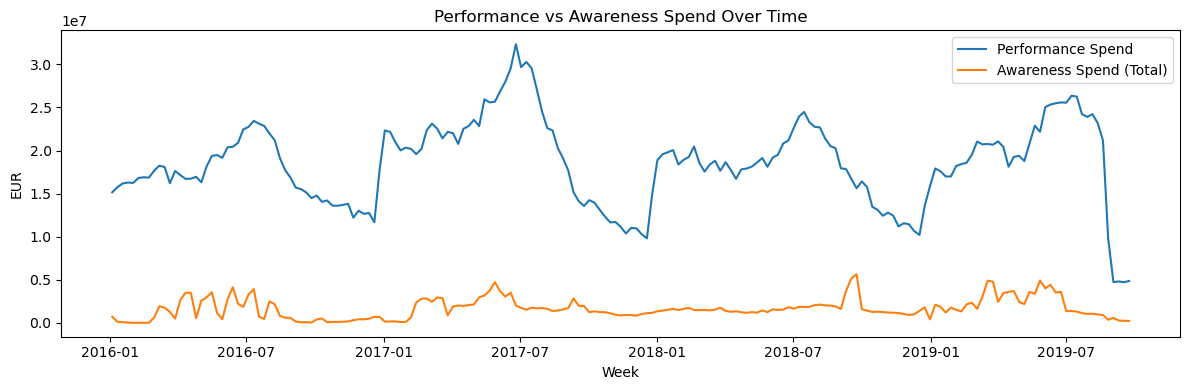

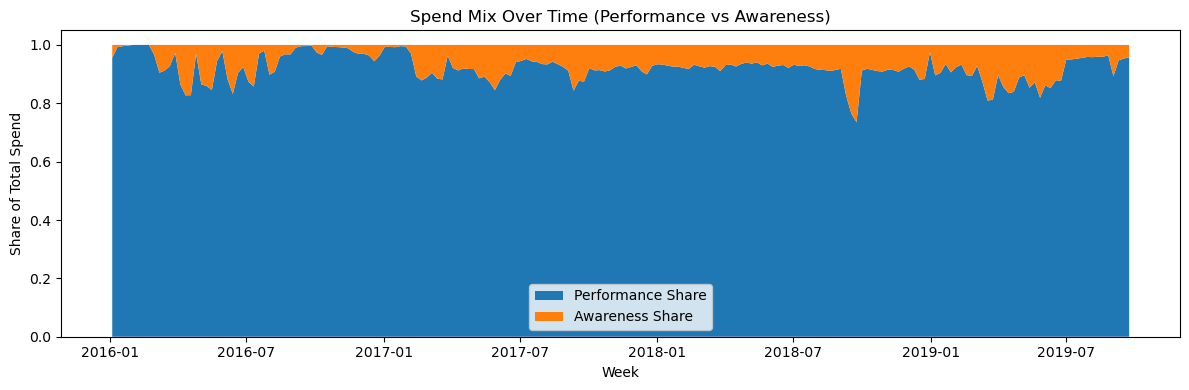

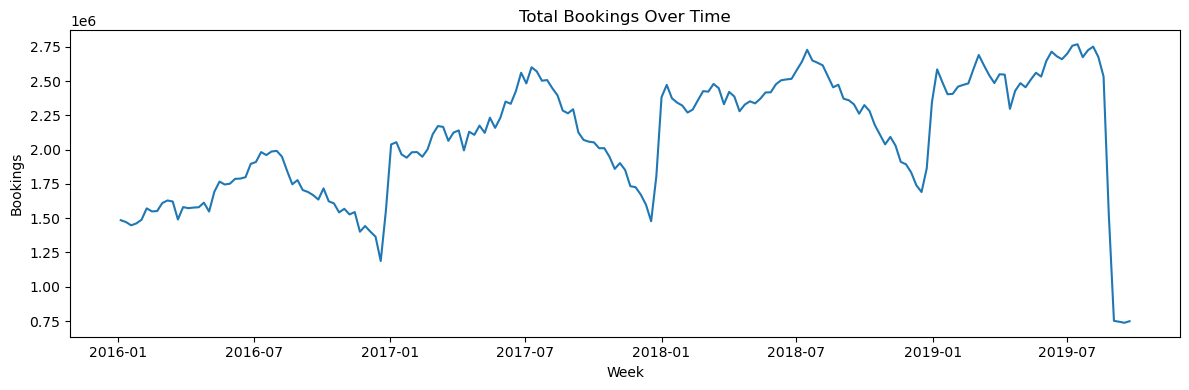

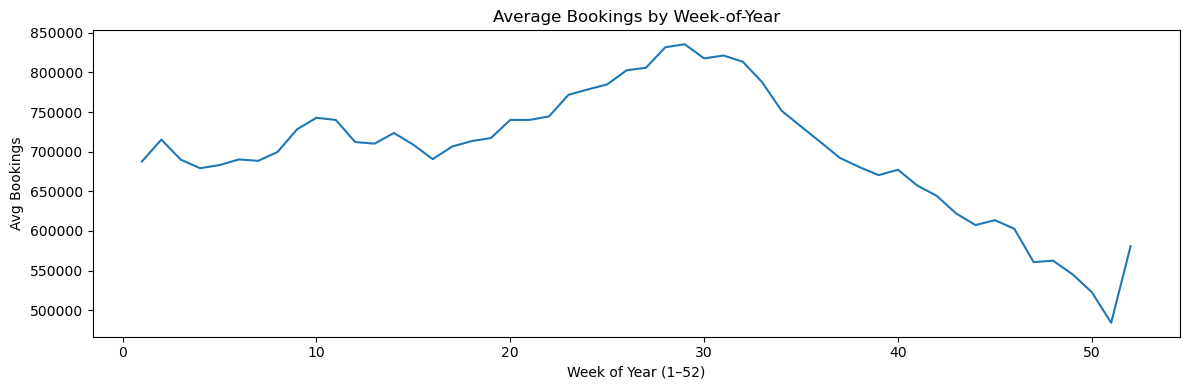

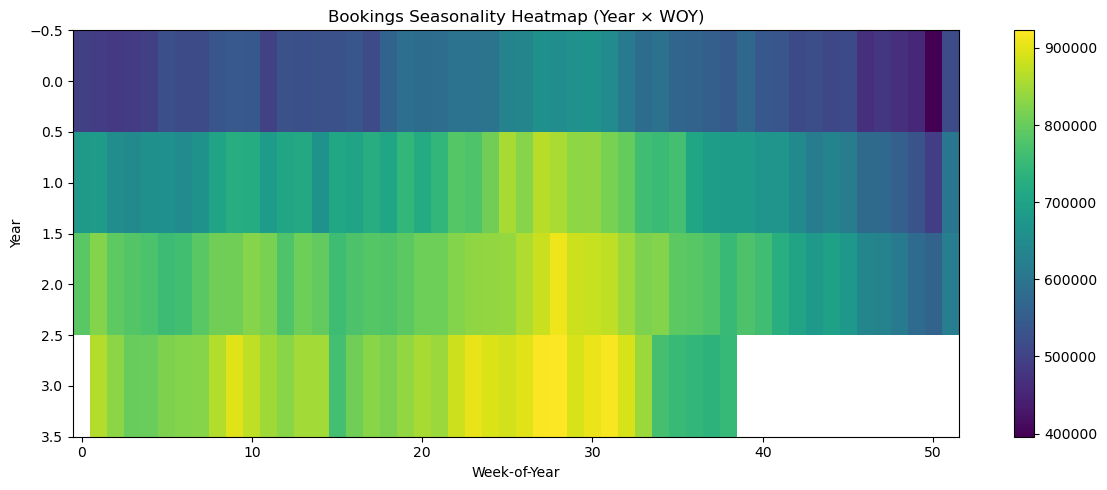

In [147]:
# ============================================================
# 2) DESCRIPTIVE ANALYTICS — Storytelling
# ============================================================

narrate("Spend mix: Performance dominates and co-moves with bookings; Awareness is smoother and mostly seasonal. Peaks cluster around holidays.")

overall_summary = df[["spend_performance","spend_awareness_total", Y_COL]].describe().T
print("Overall Summary (EUR):")
try_display(overall_summary)

by_cty = (df.groupby(GEO_COL)[["spend_performance","spend_awareness_total"]]
          .sum().sort_values("spend_performance", ascending=False))
by_cty["perf_share"]  = by_cty["spend_performance"] / (by_cty["spend_performance"] + by_cty["spend_awareness_total"]).replace(0,np.nan)
print("Country Spend & Shares (Performance vs Awareness):")
try_display(by_cty)

narrate("Now watch how spend and demand evolve together, and where the seasonal peaks land.")

ts_all = (df.groupby(TIME_COL)[[ "spend_performance","spend_awareness_total", Y_COL ]].sum().reset_index())

plt.figure()
plt.plot(ts_all[TIME_COL], ts_all["spend_performance"], label="Performance Spend")
plt.plot(ts_all[TIME_COL], ts_all["spend_awareness_total"], label="Awareness Spend (Total)")
plt.title("Performance vs Awareness Spend Over Time")
plt.xlabel("Week"); plt.ylabel("EUR"); plt.legend(); plt.tight_layout(); plt.show()

total_sp = (ts_all["spend_performance"] + ts_all["spend_awareness_total"]).replace(0,np.nan)
perf_share = (ts_all["spend_performance"]/total_sp).fillna(0.0)
aware_share = (ts_all["spend_awareness_total"]/total_sp).fillna(0.0)
plt.figure()
plt.stackplot(ts_all[TIME_COL], [perf_share, aware_share], labels=["Performance Share","Awareness Share"])
plt.title("Spend Mix Over Time (Performance vs Awareness)")
plt.xlabel("Week"); plt.ylabel("Share of Total Spend"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(ts_all[TIME_COL], ts_all[Y_COL], label="Bookings")
plt.title("Total Bookings Over Time")
plt.xlabel("Week"); plt.ylabel("Bookings"); plt.tight_layout(); plt.show()

seasonality = (df.loc[_woyf.notna()]
               .groupby(df.loc[_woyf.notna(), "woy"].astype(int))[Y_COL]
               .mean().reset_index())
plt.figure()
plt.plot(seasonality["woy"], seasonality[Y_COL])
plt.title("Average Bookings by Week-of-Year")
plt.xlabel("Week of Year (1–52)"); plt.ylabel("Avg Bookings"); plt.tight_layout(); plt.show()

df["year"] = df[TIME_COL].dt.year
pivot_season = (df.loc[_woyf.notna()]
                .groupby(["year", df.loc[_woyf.notna(), "woy"].astype(int)])[Y_COL]
                .mean().unstack(fill_value=np.nan))
plt.figure(figsize=(12,5))
plt.imshow(pivot_season, aspect="auto")
plt.title("Bookings Seasonality Heatmap (Year × WOY)")
plt.xlabel("Week-of-Year"); plt.ylabel("Year")
plt.colorbar(); plt.tight_layout(); plt.show()

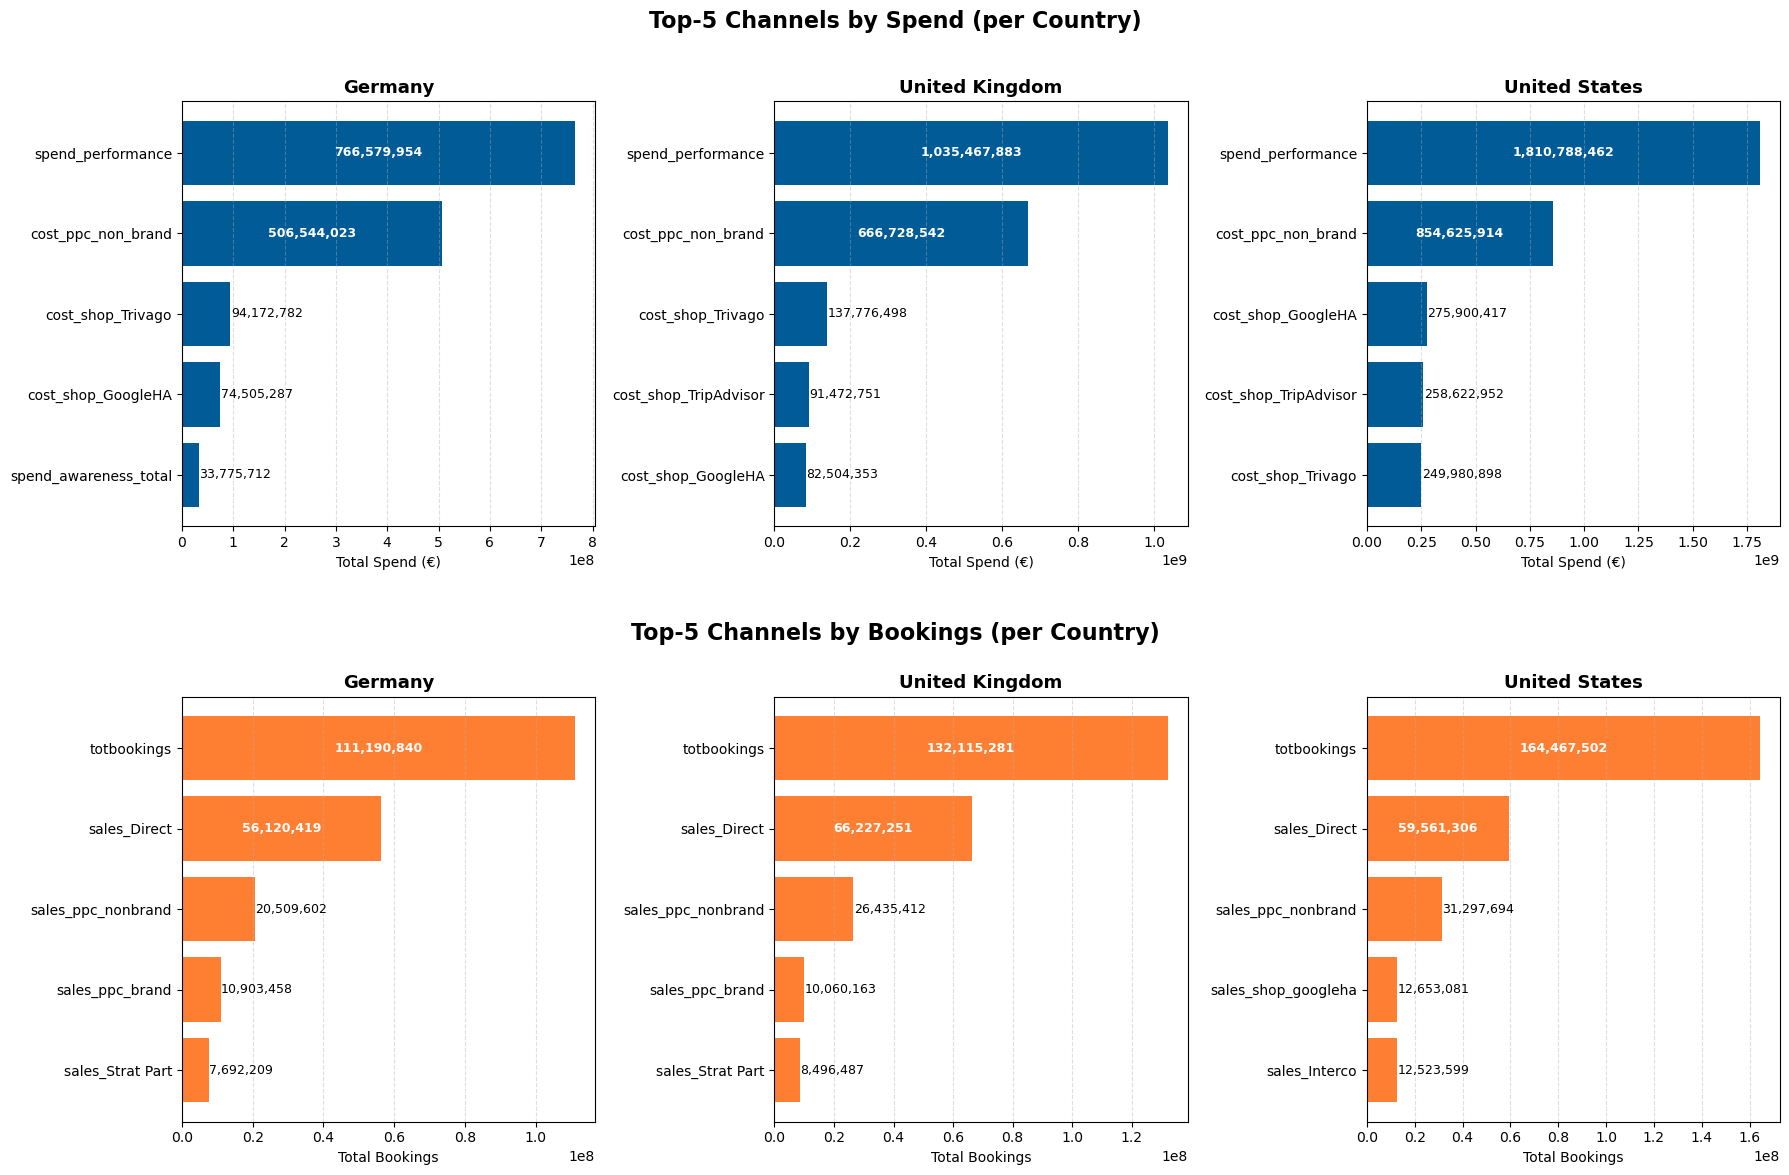

✅ Chart saved successfully as: outputs/top5_channels_summary_20251103_014545.jpg


In [148]:
# --------------------------------------------------------------
# Additional Descriptive Statistics Used in Presentation
# Added Nov 1st HH
# --------------------------------------------------------------

# --- Country name mapping ---
country_name_map = {
    "de": "Germany",
    "gb": "United Kingdom",
    "us": "United States",
}

# --- Identify relevant columns ---
spend_cols = [c for c in df.columns if "cost" in c or "spend" in c]
booking_cols = [c for c in df.columns if "sales_" in c or "bookings" in c]

# --- Melt into long format ---
df_spend = df.melt(
    id_vars=["country"],
    value_vars=spend_cols,
    var_name="channel",
    value_name="spend"
)

df_book = df.melt(
    id_vars=["country"],
    value_vars=booking_cols,
    var_name="channel",
    value_name="bookings"
)

# --- Convert country codes to readable names ---
for d in [df_spend, df_book]:
    d["country"] = d["country"].str.lower().map(country_name_map).fillna(d["country"])

# --- Aggregate total spend and bookings ---
spend_summary = (
    df_spend.groupby(["country", "channel"], as_index=False)["spend"]
    .sum()
    .sort_values(["country", "spend"], ascending=[True, False])
)

book_summary = (
    df_book.groupby(["country", "channel"], as_index=False)["bookings"]
    .sum()
    .sort_values(["country", "bookings"], ascending=[True, False])
)

# --- Select top 5 channels per country ---
top5_spend = spend_summary.groupby("country").head(5)
top5_book = book_summary.groupby("country").head(5)

# --- Determine countries ---
countries = top5_spend["country"].unique()
n_countries = len(countries)

# --- Helper function to add labels ---
def add_labels(ax, bars):
    n = len(bars)
    for i, bar in enumerate(bars):
        width = bar.get_width()
        if i >= n - 2:  # top 2 bars: label inside
            ax.text(
                width * 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{width:,.0f}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold"
            )
        else:  # others: label outside
            ax.text(
                width + (width * 0.01),
                bar.get_y() + bar.get_height() / 2,
                f"{width:,.0f}",
                ha="left",
                va="center",
                color="black",
                fontsize=9
            )

# --- Create subplots: 2 rows × n_countries columns ---
fig, axes = plt.subplots(
    nrows=2,
    ncols=n_countries,
    figsize=(6 * n_countries, 12),
    sharey=False
)

if n_countries == 1:
    axes = [axes]

# --- Add section headings ---
fig.text(0.5, 0.96, "Top-5 Channels by Spend (per Country)",
         ha="center", fontsize=16, fontweight="bold")

fig.text(0.5, 0.45, "Top-5 Channels by Bookings (per Country)",
         ha="center", fontsize=16, fontweight="bold")

# --- Plot Top 5 by Spend ---
for ax, cty in zip(axes[0], countries):
    subset = top5_spend[top5_spend["country"] == cty].sort_values("spend", ascending=True)
    bars = ax.barh(subset["channel"], subset["spend"], color="#005B96")
    ax.set_title(f"{cty}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Total Spend (€)")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.tick_params(axis="y", labelrotation=0)
    add_labels(ax, bars)

# --- Plot Top 5 by Bookings ---
for ax, cty in zip(axes[1], countries):
    subset = top5_book[top5_book["country"] == cty].sort_values("bookings", ascending=True)
    bars = ax.barh(subset["channel"], subset["bookings"], color="#FF7F32")
    ax.set_title(f"{cty}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Total Bookings")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.tick_params(axis="y", labelrotation=0)
    add_labels(ax, bars)

# --- Adjust layout so both headings have room ---
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.subplots_adjust(hspace=0.4)

# --- Save figure to JPG with timestamp ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"outputs/top5_channels_summary_{timestamp}.jpg"
plt.savefig(output_path, dpi=300, bbox_inches="tight", format="jpg")

# --- Display chart ---
plt.show()

print(f"✅ Chart saved successfully as: {output_path}")


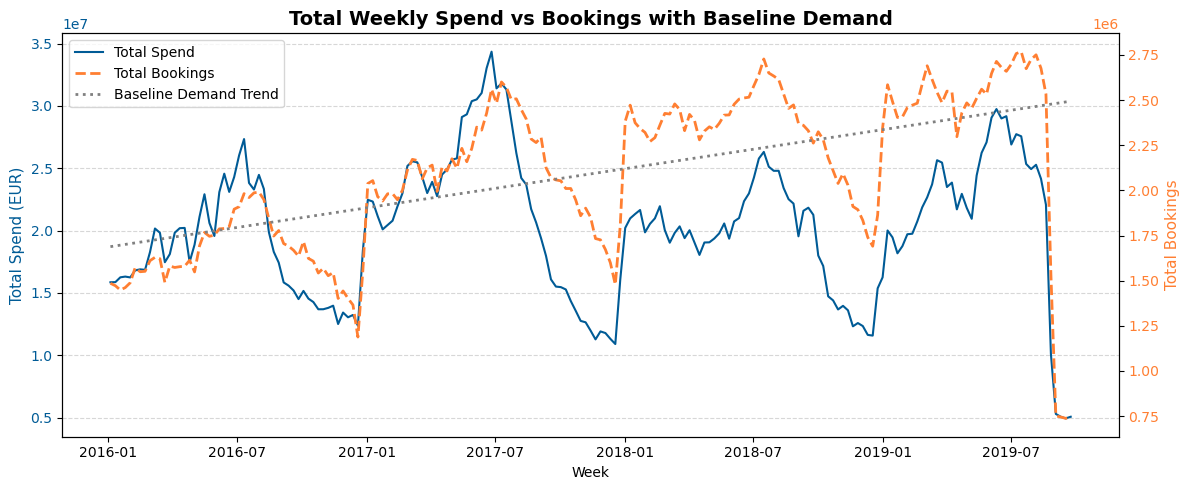

In [149]:
# Added Nov 1st HH

from scipy.stats import linregress

# --- Aggregate weekly totals ---
weeklyVisual = (
    df.groupby("weekstart", as_index=False)
      .agg({
          "spend_performance": "sum",
          "spend_awareness_total": "sum",
          "totbookings": "sum"
      })
)

# --- Total spend and baseline (trend) ---
weeklyVisual["total_spend"] = weeklyVisual["spend_performance"] + weeklyVisual["spend_awareness_total"]

# Compute a simple linear baseline trend across bookings
x = np.arange(len(weeklyVisual))
slope, intercept, _, _, _ = linregress(x, weeklyVisual["totbookings"])
weeklyVisual["baseline_trend"] = intercept + slope * x

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 5))

# Spend line (left y-axis)
ax1.plot(weeklyVisual["weekstart"], weeklyVisual["total_spend"], color="#005B96", label="Total Spend")
ax1.set_ylabel("Total Spend (EUR)", color="#005B96", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#005B96")

# Bookings (right y-axis)
ax2 = ax1.twinx()
ax2.plot(weeklyVisual["weekstart"], weeklyVisual["totbookings"], color="#FF7F32", linestyle="--", linewidth=2, label="Total Bookings")
ax2.set_ylabel("Total Bookings", color="#FF7F32", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#FF7F32")

# Baseline demand trend (on bookings axis for consistency)
ax2.plot(weeklyVisual["weekstart"], weeklyVisual["baseline_trend"], color="gray", linestyle=":", linewidth=2, label="Baseline Demand Trend")

# Titles & labels
plt.title("Total Weekly Spend vs Bookings with Baseline Demand", fontsize=14, fontweight="bold")
ax1.set_xlabel("Week")

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True)

# Grid & style tweaks
ax1.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# --- Optional: Save as JPG ---
plt.savefig("outputs/weekly_spend_vs_bookings.jpg", dpi=300, bbox_inches="tight")

plt.show()



✅ Saved: outputs/seasonal_trend_spend_DE.jpg


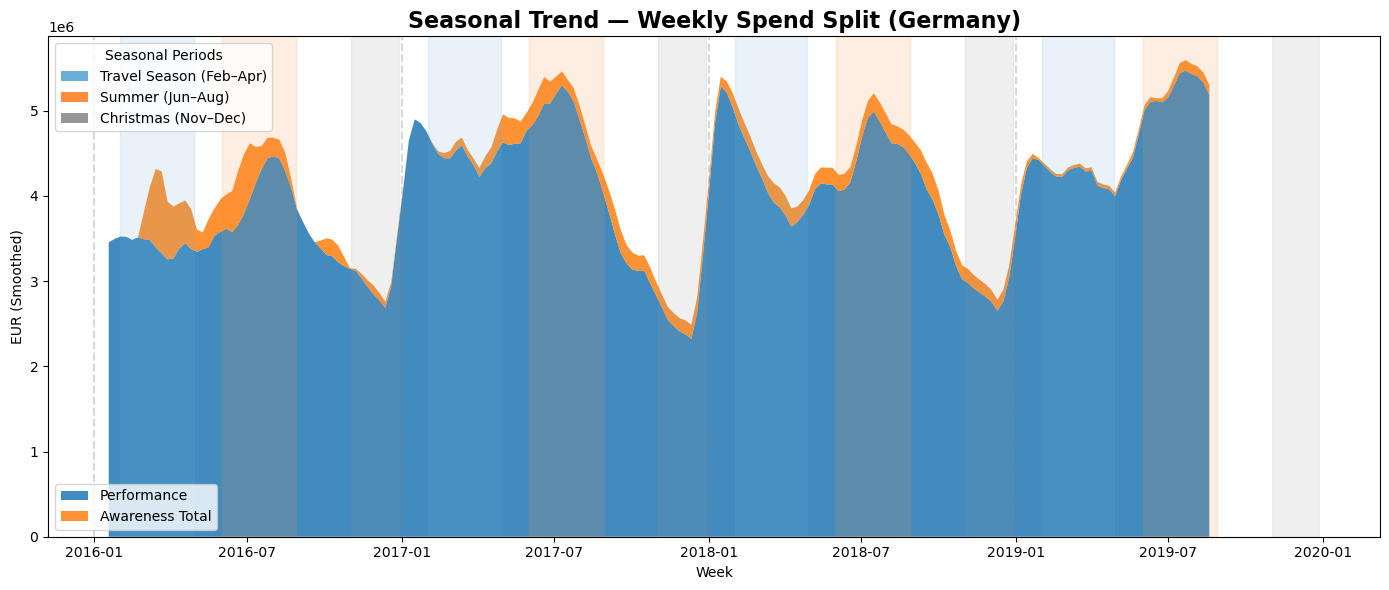

✅ Saved: outputs/seasonal_trend_spend_GB.jpg


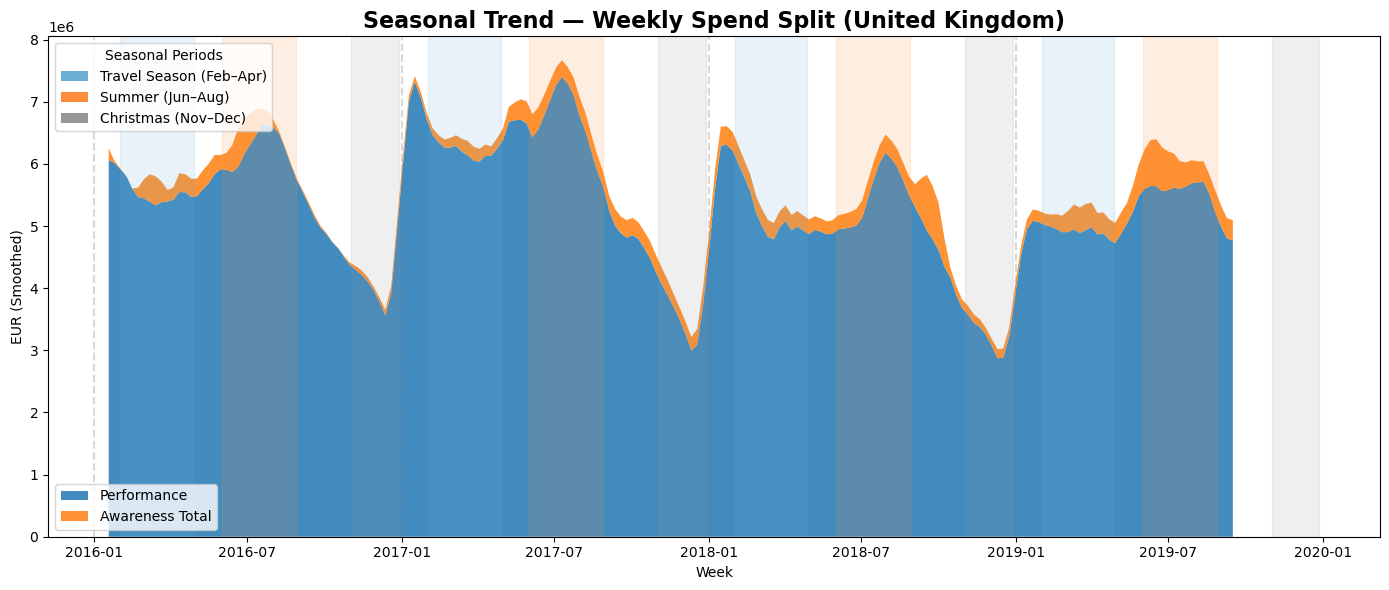

✅ Saved: outputs/seasonal_trend_spend_US.jpg


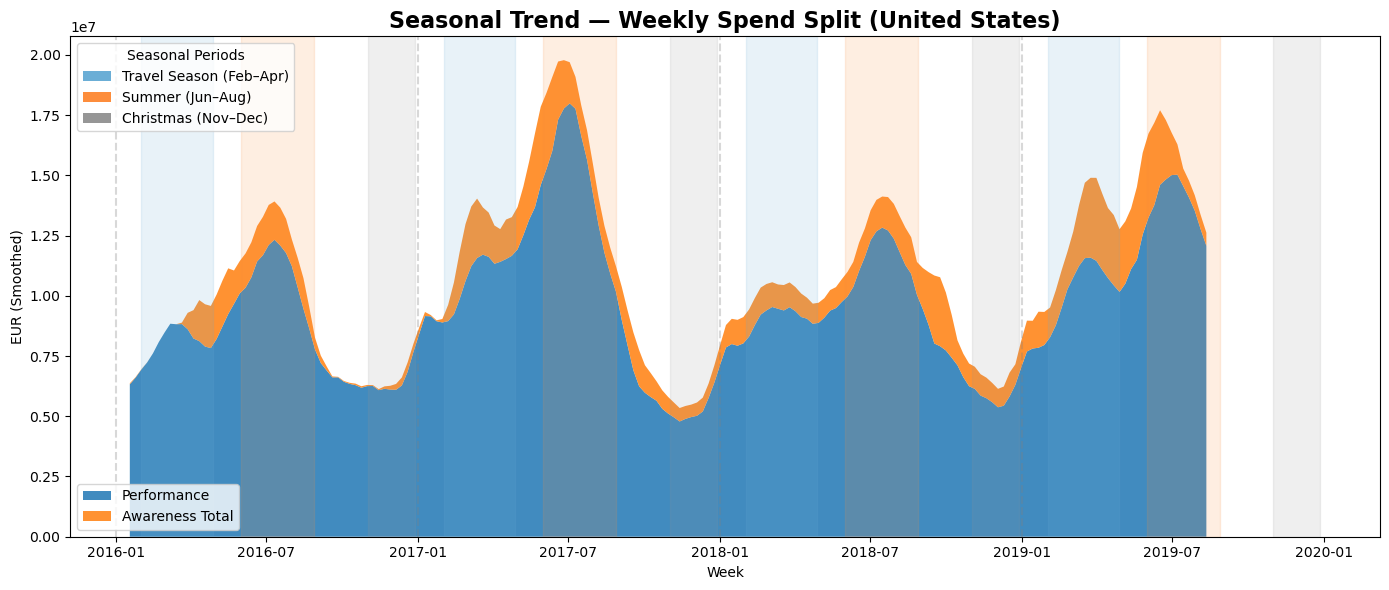

In [150]:
# Added Nov 1st HH
import seaborn as sns
from matplotlib.patches import Patch

# --- Country name map for display titles ---
country_display_names = {
    "de": "Germany",
    "gb": "United Kingdom",
    "us": "United States"
}

# --- Define function to create seasonal trend chart ---
def plot_seasonal_trend(df, country, save=True):
    # --- Filter and prepare data ---
    df_country = df[df["country"].str.lower() == country.lower()].copy()
    df_country = df_country.sort_values("weekstart")

    weekly = (
        df_country.groupby("weekstart", as_index=False)
                  .agg({
                      "spend_performance": "sum",
                      "spend_awareness_total": "sum"
                  })
    )

    # --- Rolling average (4-week window) ---
    weekly["perf_trend"] = weekly["spend_performance"].rolling(4, center=True).mean()
    weekly["aware_trend"] = weekly["spend_awareness_total"].rolling(4, center=True).mean()
    weekly["total_trend"] = weekly["perf_trend"] + weekly["aware_trend"]

    # --- Create figure ---
    fig, ax = plt.subplots(figsize=(14, 6))

    # --- Stacked area ---
    ax.stackplot(
        weekly["weekstart"],
        weekly["perf_trend"],
        weekly["aware_trend"],
        labels=["Performance", "Awareness Total"],
        colors=["#1f77b4", "#ff7f0e"],
        alpha=0.85
    )

    # --- Define shaded seasonal regions ---
    def add_season(ax, start_month, end_month, color):
        """Add shaded background for given months across all years."""
        for year in weekly["weekstart"].dt.year.unique():
            start = pd.Timestamp(year=year, month=start_month, day=1)
            end = pd.Timestamp(year=year, month=end_month, day=28)
            ax.axvspan(start, end, color=color, alpha=0.15)

    # --- Add shading for seasons ---
    add_season(ax, 2, 4, "#6baed6")   # Travel Season
    add_season(ax, 6, 8, "#fd8d3c")   # Summer
    add_season(ax, 11, 12, "#969696") # Christmas

    # --- Formatting ---
    display_name = country_display_names.get(country.lower(), country.upper())
    ax.set_title(f"Seasonal Trend — Weekly Spend Split ({display_name})", fontsize=16, fontweight="bold")
    ax.set_xlabel("Week")
    ax.set_ylabel("EUR (Smoothed)")
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    # --- Legends ---
    main_legend = ax.legend(loc="lower left", frameon=True)

    season_patches = [
        Patch(facecolor="#6baed6", alpha=1.0, label="Travel Season (Feb–Apr)"),
        Patch(facecolor="#fd8d3c", alpha=1.0, label="Summer (Jun–Aug)"),
        Patch(facecolor="#969696", alpha=1.0, label="Christmas (Nov–Dec)")
    ]
    season_legend = ax.legend(
        handles=season_patches,
        loc="upper left",
        frameon=True,
        title="Seasonal Periods"
    )

    ax.add_artist(main_legend)

    # --- Add year dividers ---
    for year in weekly["weekstart"].dt.year.unique():
        ax.axvline(pd.Timestamp(f"{year}-01-01"), color="gray", linestyle="--", alpha=0.3)

    plt.tight_layout()

    # --- Save chart ---
    if save:
        filename = f"outputs/seasonal_trend_spend_{country.upper()}.jpg"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {filename}")

    plt.show()

# --- Generate plots for Germany, UK, and US ---
for c in ["de", "gb", "us"]:
    plot_seasonal_trend(df, c)


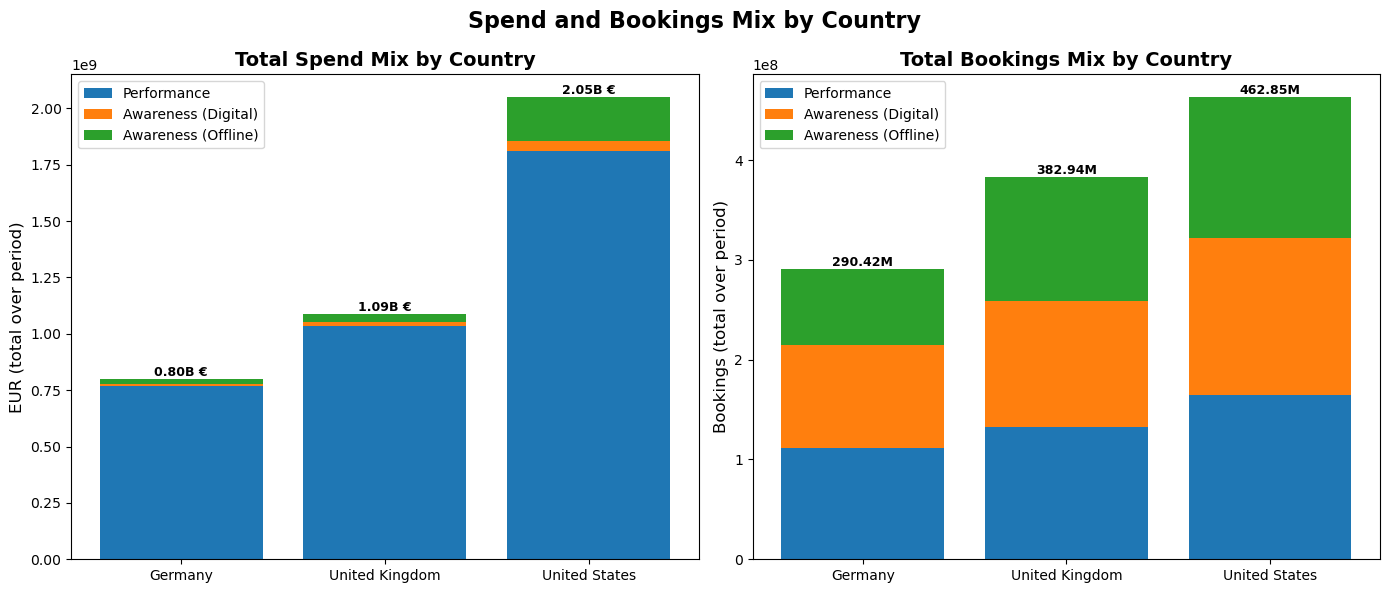

In [151]:
# Added Nov 1st HH

# --- Map country codes to names ---
country_name_map = {
    "de": "Germany",
    "gb": "United Kingdom",
    "us": "United States"
}

df_visual=df.copy()

#df_visual["bookings_performance"]      = df_visual[PERFORMANCE_COLS].sum(axis=1) if PERFORMANCE_COLS else 0.0
#df_visual["bookings_awareness_dig"]    = df_visual[DIGITAL_AWARENESS].sum(axis=1) if DIGITAL_AWARENESS else 0.0
#df_visual["bookings_awareness_off"]    = df_visual[OFFLINE_AWARENESS].sum(axis=1) if OFFLINE_AWARENESS else 0.0

df_visual["bookings_performance"] = df_visual["totbookings"].where(df["spend_performance"] > 0, 0)
df_visual["bookings_awareness_dig"] = df_visual["totbookings"].where(df["spend_awareness_dig"] > 0, 0)
df_visual["bookings_awareness_off"] = df_visual["totbookings"].where(df["spend_awareness_off"] > 0, 0)

# --- Aggregate spend and total bookings by country ---
spend_bookings_summary = (
    df_visual.groupby("country", as_index=False)
      .agg({
          "spend_performance": "sum",
          "spend_awareness_dig": "sum",
          "spend_awareness_off": "sum",
          "bookings_performance": "sum",
          "bookings_awareness_dig": "sum",
          "bookings_awareness_off": "sum"
      })
)

# --- Convert country codes to readable names ---
spend_bookings_summary["country"] = (
    spend_bookings_summary["country"]
    .str.lower()
    .map(country_name_map)
    .fillna(spend_bookings_summary["country"])
)

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# ======== LEFT: SPEND MIX ========
ax1 = axes[0]
ax1.bar(spend_bookings_summary["country"], spend_bookings_summary["spend_performance"], label="Performance", color="#1f77b4")
ax1.bar(spend_bookings_summary["country"], spend_bookings_summary["spend_awareness_dig"],
        bottom=spend_bookings_summary["spend_performance"], label="Awareness (Digital)", color="#ff7f0e")
ax1.bar(spend_bookings_summary["country"],
        spend_bookings_summary["spend_awareness_off"],
        bottom=spend_bookings_summary["spend_performance"] + spend_bookings_summary["spend_awareness_dig"],
        label="Awareness (Offline)", color="#2ca02c")

ax1.set_title("Total Spend Mix by Country", fontsize=14, fontweight="bold")
ax1.set_ylabel("EUR (total over period)", fontsize=12)
ax1.set_facecolor("white")
ax1.legend(frameon=True, loc="upper left")

# --- Add spend labels ---
for idx, row in spend_bookings_summary.iterrows():
    total_spend = row["spend_performance"] + row["spend_awareness_dig"] + row["spend_awareness_off"]
    ax1.text(
        idx,
        total_spend,
        f"{total_spend/1e9:.2f}B €",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ======== RIGHT: BOOKINGS MIX ========
ax2 = axes[1]
ax2.bar(spend_bookings_summary["country"], spend_bookings_summary["bookings_performance"], label="Performance", color="#1f77b4")
ax2.bar(spend_bookings_summary["country"], spend_bookings_summary["bookings_awareness_dig"],
        bottom=spend_bookings_summary["bookings_performance"], label="Awareness (Digital)", color="#ff7f0e")
ax2.bar(spend_bookings_summary["country"],
        spend_bookings_summary["bookings_awareness_off"],
        bottom=spend_bookings_summary["bookings_performance"] + spend_bookings_summary["bookings_awareness_dig"],
        label="Awareness (Offline)", color="#2ca02c")

ax2.set_title("Total Bookings Mix by Country", fontsize=14, fontweight="bold")
ax2.set_ylabel("Bookings (total over period)", fontsize=12)
ax2.set_facecolor("white")
ax2.legend(frameon=True, loc="upper left")

# --- Add bookings labels ---
for idx, row in spend_bookings_summary.iterrows():
    total_bookings = row["bookings_performance"] + row["bookings_awareness_dig"] + row["bookings_awareness_off"]
    ax2.text(
        idx,
        total_bookings,
        f"{total_bookings/1e6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ======== Final formatting ========
fig.suptitle("Spend and Bookings Mix by Country", fontsize=16, fontweight="bold")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig("outputs/spend_and_bookings_mix_by_country.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [152]:
# Added Nov 3rd YT

# --- Marketing Budget Proportions (Overall + By Country) ---

# Column definitions based on your dataset
SPEND_COLS = ["spend_performance", "spend_awareness_dig", "spend_awareness_off"]

# Overall marketing budget proportions (% of total)
spend_totals = df[SPEND_COLS].apply(pd.to_numeric, errors="coerce").sum()
overall_props = (spend_totals / spend_totals.sum() * 100).round(2)
overall_props.index = ["Performance %", "Awareness (Digital) %", "Awareness (Offline) %"]

print("Marketing Budget Distribution (Overall):")
print(overall_props)
print()

# Marketing budget proportions by country (% of each country's total)
by_cty = (
    df.groupby("country")[SPEND_COLS]
      .sum(min_count=1)
      .pipe(lambda g: g.div(g.sum(axis=1), axis=0) * 100)
      .round(2)
      .rename(columns={
          "spend_performance": "Performance %",
          "spend_awareness_dig": "Awareness (Digital) %",
          "spend_awareness_off": "Awareness (Offline) %"
      })
)

# Safe mapping of country codes to readable names
country_name_map = {"de": "Germany", "gb": "United Kingdom", "us": "United States"}
by_cty.index = [country_name_map.get(str(i).lower(), i) for i in by_cty.index]

print("Marketing Budget Distribution by Country (%):")
print(by_cty)


Marketing Budget Distribution (Overall):
Performance %            91.80
Awareness (Digital) %     1.79
Awareness (Offline) %     6.41
dtype: float64

Marketing Budget Distribution by Country (%):
                Performance %  Awareness (Digital) %  Awareness (Offline) %
Germany                 95.78                   1.16                   3.06
United Kingdom          95.30                   1.63                   3.06
United States           88.40                   2.11                   9.49


In [153]:
# Added Nov 3rd YT

# --- Calculate Total Annual Spend and Average (2016–2019) ---

# Replace column names if different in your dataset
SPEND_COLS = ["spend_performance", "spend_awareness_dig", "spend_awareness_off"]

# Make sure these exist in df
df["total_spend"] = df[SPEND_COLS].sum(axis=1)

# Group by year (assuming there's a 'year' column)
annual_spend = (
    df.groupby("year")["total_spend"]
      .sum()
      .sort_index()
      .apply(lambda x: x / 1e9)  # convert to billions for readability
      .round(3)
)

# Compute the multi-year average
avg_spend = annual_spend.mean().round(3)

print("Annual Total Marketing Spend (in € Billions):")
print(annual_spend)
print(f"\nAverage Annual Spend (2016–2019): ≈ €{avg_spend} B")

Annual Total Marketing Spend (in € Billions):
year
2016.0    0.948
2017.0    1.139
2018.0    1.028
2019.0    0.820
Name: total_spend, dtype: float64

Average Annual Spend (2016–2019): ≈ €0.984 B


In [154]:
# ============================================================
# 3) FEATURE ENGINEERING (adstock + saturation)
# ============================================================

narrate("Convert euros to behavioral pressure: adstock (memory) + log saturation. The model sees these, not raw spend.")

df["adstock_perf"]  = np.nan
df["adstock_aware"] = np.nan
for cty, g in df.groupby(GEO_COL):
    idx = g.index
    df.loc[idx, "adstock_perf"]  = adstock_geometric(g["spend_performance"],     ADSTOCK_ALPHA, ADSTOCK_LAGS).values
    df.loc[idx, "adstock_aware"] = adstock_geometric(g["spend_awareness_total"], ADSTOCK_ALPHA, ADSTOCK_LAGS).values

df["f_perf"]  = np.log1p(df["adstock_perf"])
df["f_aware"] = np.log1p(df["adstock_aware"])

# Fallback f_brand = f_aware (so we can orthogonalize f_perf vs brand-like driver)
df["f_brand"] = df["f_aware"]

# Response (log)
df["y"] = np.log1p(df[Y_COL].clip(lower=0))


[Story] Convert euros to behavioral pressure: adstock (memory) + log saturation. The model sees these, not raw spend.



In [155]:
# --------------------------------------------
# Save processed dataset (safe)
# Added Nov 1st HH
# --------------------------------------------
import os
def save_csv_safely(df: pd.DataFrame,
                    preferred_name: str = "processed_marketing_data.csv",
                    out_dir: str = "outputs") -> str:
    os.makedirs(out_dir, exist_ok=True)
    base_path = os.path.join(out_dir, preferred_name)
    tmp_path  = base_path + ".tmp"
    try:
        df.to_csv(tmp_path, index=False)
        os.replace(tmp_path, base_path)
        print(f"Processed data saved to: {base_path}")
        return base_path
    except PermissionError:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        alt = os.path.join(out_dir, f"{os.path.splitext(preferred_name)[0]}_{ts}.csv")
        df.to_csv(alt, index=False)
        print(f"⚠️ Primary path locked. Saved to: {alt}")
        return alt
    except OSError as e:
        print(f"⚠️ Save to '{out_dir}' failed: {e}. Trying CWD...")
        alt = os.path.join(os.getcwd(), f"{os.path.splitext(preferred_name)[0]}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")
        df.to_csv(alt, index=False)
        print(f"Processed data saved to: {alt}")
        return alt

_ = save_csv_safely(df, preferred_name="processed_marketing_data_withEngineeredFeatures.csv", out_dir="outputs")

Processed data saved to: outputs/processed_marketing_data_withEngineeredFeatures.csv


In [156]:

# ============================================================
# 4) DESIGN MATRIX (orthogonalized): low-VIF build
# ============================================================

narrate("Separate level and slope, then orthogonalize f_perf vs {brand/time/country/FX}. This keeps VIF in check and preserves the f_perf signal.")

def _center_within_country(s: pd.Series, geo: pd.Series) -> pd.Series:
    s_num = pd.to_numeric(s, errors="coerce").fillna(0.0)
    return s_num - s_num.groupby(geo).transform("mean")

def _detect_country_level_controls(df_: pd.DataFrame) -> list[str]:
    keys = ["fx", "curr", "currency", "exch", "rate", "value"]
    out = []
    for c in df_.columns:
        lc = str(c).lower()
        if any(k in lc for k in keys) and c not in {"f_perf","f_aware","f_brand","y"}:
            if pd.api.types.is_numeric_dtype(df_[c]):
                out.append(c)
    return out

def build_X_brandstock_lowVIF_ortho(df_input: pd.DataFrame,
                                    geo_col: str,
                                    time_cols=("t","sin_woy","cos_woy"),
                                    drop_first=True):
    dfb = df_input.copy()

    # GEO baseline + handle missing GEO by mapping to baseline to avoid cty_nan
    geo_raw = dfb[geo_col].astype("object")
    valid_mask = ~geo_raw.isna() & (geo_raw.astype(str).str.strip().str.lower() != "nan") & (geo_raw.astype(str).str.strip() != "")
    baseline = (geo_raw[valid_mask].astype(str).value_counts().idxmax() if valid_mask.any() else "baseline")
    geo = geo_raw.astype("object").copy()
    geo[~valid_mask] = baseline

    cats = [baseline] + [c for c in geo.astype(str).value_counts().index if c != baseline]
    geo_cat = pd.Categorical(geo.astype(str), categories=cats, ordered=False)
    dums = pd.get_dummies(geo_cat, prefix="cty", drop_first=drop_first, dtype=float)

    def _center_within_country(s: pd.Series, geo_s: pd.Series) -> pd.Series:
        s_num = pd.to_numeric(s, errors="coerce").fillna(0.0)
        return s_num - s_num.groupby(geo_s).transform("mean")

    def _detect_country_level_controls(df_: pd.DataFrame) -> list[str]:
        keys = ["fx", "curr", "currency", "exch", "rate", "value"]
        out = []
        for c in df_.columns:
            lc = str(c).lower()
            if any(k in lc for k in keys) and c not in {"f_perf","f_aware","f_brand","y"}:
                if pd.api.types.is_numeric_dtype(df_[c]):
                    out.append(c)
        return out

    # Center drivers within country
    f_perf_c  = _center_within_country(dfb["f_perf"],  geo)
    f_aware_c = _center_within_country(dfb["f_aware"], geo)
    f_brand_c = _center_within_country(dfb["f_brand"], geo)

    # Base matrix (centered globals)
    X_new = pd.DataFrame({"f_perf": f_perf_c, "f_aware": f_aware_c, "f_brand": f_brand_c}, index=dfb.index)

    # Time controls (as-is)
    for c in time_cols:
        if c in dfb.columns:
            X_new[c] = pd.to_numeric(dfb[c], errors="coerce").fillna(0.0)

    # Country intercepts (K–1)
    if len(dums.columns):
        X_new = pd.concat([X_new, dums], axis=1)

    # Country-level controls (FX etc.) centered within country
    fx_cols = _detect_country_level_controls(dfb)
    for c in fx_cols:
        X_new[f"{c}_c"] = _center_within_country(dfb[c], geo)

    # ORTHOGONALIZE f_perf vs {f_brand, time, country dummies, centered FX}
    Z = pd.DataFrame(index=X_new.index)
    Z["const"]   = 1.0
    Z["f_brand"] = X_new["f_brand"]
    for c in time_cols:
        if c in X_new.columns:
            Z[c] = X_new[c]
    for c in dums.columns:
        Z[c] = dums[c]
    for c in fx_cols:
        cname = f"{c}_c"
        if cname in X_new.columns:
            Z[cname] = X_new[cname]

    beta, *_ = np.linalg.lstsq(Z.values, X_new["f_perf"].values, rcond=None)
    f_perf_orth = X_new["f_perf"] - Z.values @ beta

    # Replace f_perf with orthogonalized series; keep per-country slopes ONLY for f_perf
    X_new["f_perf"] = f_perf_orth
    if len(dums.columns):
        for d in dums.columns:
            X_new[f"f_perf:{d}"] = f_perf_orth.values * dums[d].values

    # Global interaction with brand, using orthogonalized f_perf
    X_new["f_perf_x_brand"] = f_perf_orth * X_new["f_brand"]

    X_new = dedupe_columns(make_numeric_float_no_nan(X_new))

    # --- store artifacts needed to rebuild scenarios consistently ---
    def _means_by_geo(s): 
        s = pd.to_numeric(s, errors="coerce").fillna(0.0)
        return s.groupby(geo).mean().to_dict()
    geo_means = {
        "f_perf":  _means_by_geo(dfb["f_perf"]),
        "f_aware": _means_by_geo(dfb["f_aware"]),
        "f_brand": _means_by_geo(dfb["f_brand"]),
    }
    for c in fx_cols:
        geo_means[f"{c}"] = _means_by_geo(dfb[c])

    ortho = {
        "beta": beta,                           # np.array aligned to Z_cols
        "Z_cols": list(Z.columns),              # ["const","f_brand",time..., dums..., fx_c...]
        "time_cols": list(time_cols),
        "dums_cols": list(dums.columns),
        "fx_cols": list(fx_cols),
        "geo": geo.astype(str),                 # Series aligned to df index
        "geo_levels": cats,
        "baseline_label": baseline,
        "geo_means": geo_means,                 # dict[var][geo] -> mean
    }

    return X_new, dums, baseline, int((~valid_mask).sum()), fx_cols, ortho

# Build orthogonalized design
X, cty_dums, _baseline_country, _geo_missing_to_baseline, _fx_cols, ORTHO = build_X_brandstock_lowVIF_ortho(df, GEO_COL)
y = pd.to_numeric(df["y"], errors="coerce").fillna(0.0).astype("float64")

print(f"Rebuilt X (orthogonalized). Baseline country = {_baseline_country}. Missing GEO rows assigned to baseline = {_geo_missing_to_baseline}.")
if _fx_cols:
    print(f"Centered country-level controls within country: {_fx_cols}")

print("VIF (top 15) after orthogonalization:")
vif_top15 = compute_vif(X).head(15)
try_display(vif_top15)
explain_vif(vif_top15)



[Story] Separate level and slope, then orthogonalize f_perf vs {brand/time/country/FX}. This keeps VIF in check and preserves the f_perf signal.

Rebuilt X (orthogonalized). Baseline country = gb. Missing GEO rows assigned to baseline = 15.
Centered country-level controls within country: ['value (currency rate)']
VIF (top 15) after orthogonalization:


,feature,vif
8,value (currency rate)_c,6.576576
11,f_perf_x_brand,3.777928
9,f_perf:cty_de,2.133106
0,f_perf,2.081775
10,f_perf:cty_us,1.914484
3,t,1.669539
6,cty_de,1.512169
7,cty_us,1.327632
5,cos_woy,1.203541
4,sin_woy,1.147807



[VIF quick read]
                feature      vif
value (currency rate)_c 6.576576
         f_perf_x_brand 3.777928
          f_perf:cty_de 2.133106
                 f_perf 2.081775
          f_perf:cty_us 1.914484
                      t 1.669539
Most VIFs ≤ ~10. Acceptable; keep an eye on shared variance among controls.



[Story] Baseline HAC-robust fit. f_perf is materially positive; f_aware is small on weekly bookings. Holidays act as expected.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     7456.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:45:46   Log-Likelihood:                 558.81
No. Observations:                 591   AIC:                            -1094.
Df Residuals:                     579   BIC:                            -1041.
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025  

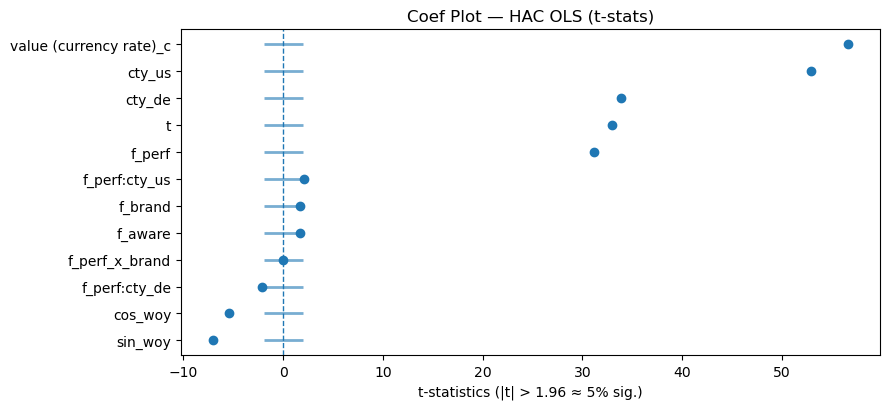

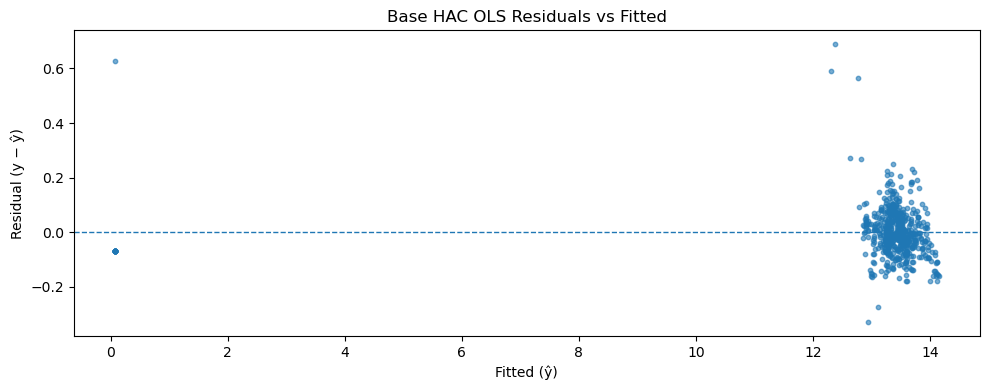

<Figure size 500x500 with 0 Axes>

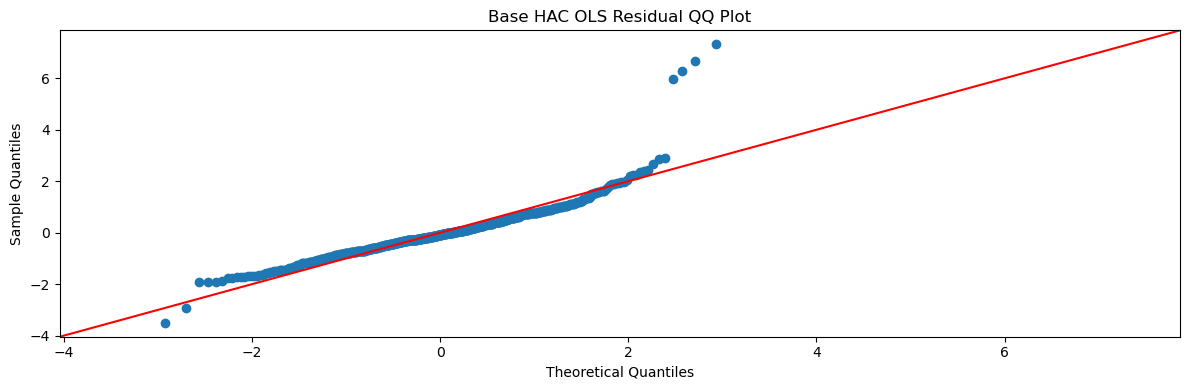

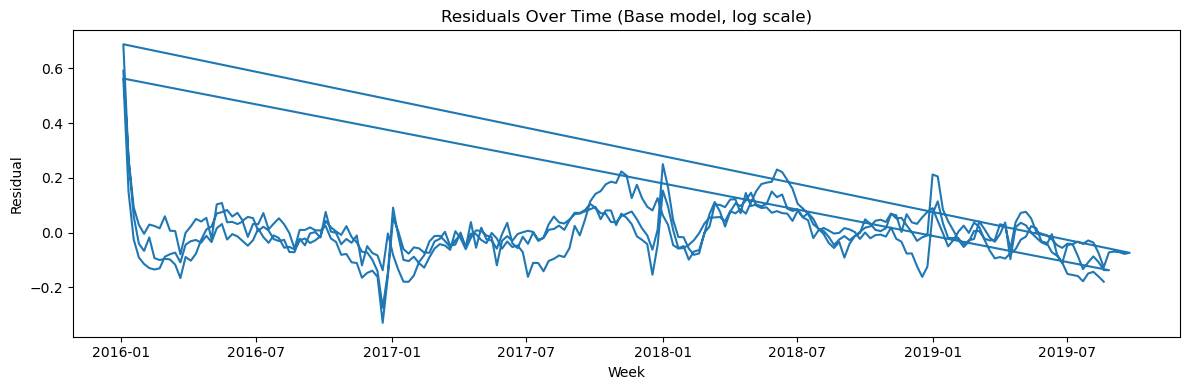

In [157]:
# ============================================================
# 5) BASE MODEL — HAC OLS (before AR correction) + Coef Plot
# ============================================================

narrate("Baseline HAC-robust fit. f_perf is materially positive; f_aware is small on weekly bookings. Holidays act as expected.")

hac_lags = 8
model_base = hac_ols(y, X, maxlags=hac_lags)

# Base model summary
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=SMValueWarning)
    print(model_base.summary())

# Coefficient plot (t-stats)
narrate("Visual inference: which features actually pull weight? (Coefficient plot by t-statistics)")
coefplot_sm(model_base, method="tstats", title="Coef Plot — HAC OLS (t-stats)", top_n=20)

# --- Residual diagnostics (NEW) ---
X1 = add_constant(X, has_constant="add")
X1 = make_numeric_float_no_nan(X1)
yhat_base = model_base.predict(X1)

# Residuals vs Fitted + QQ (NEW)
resid_base = residual_diagnostics(y, yhat_base, title_prefix="Base HAC OLS")

# Optional: residuals over time
plt.figure()
plt.plot(df[TIME_COL], resid_base)
plt.title("Residuals Over Time (Base model, log scale)")
plt.xlabel("Week"); plt.ylabel("Residual")
plt.tight_layout(); plt.show()


[Story] There’s AR(1) in weekly noise. After a light AR(1) correction the f_perf signal holds and inference is cleaner.

Estimated AR(1) rho (avg across countries): 0.783
                            OLS Regression Results                            
Dep. Variable:                 y_star   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     55.04
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           7.39e-82
Time:                        01:45:46   Log-Likelihood:                 947.55
No. Observations:                 573   AIC:                            -1871.
Df Residuals:                     561   BIC:                            -1819.
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                              coef    

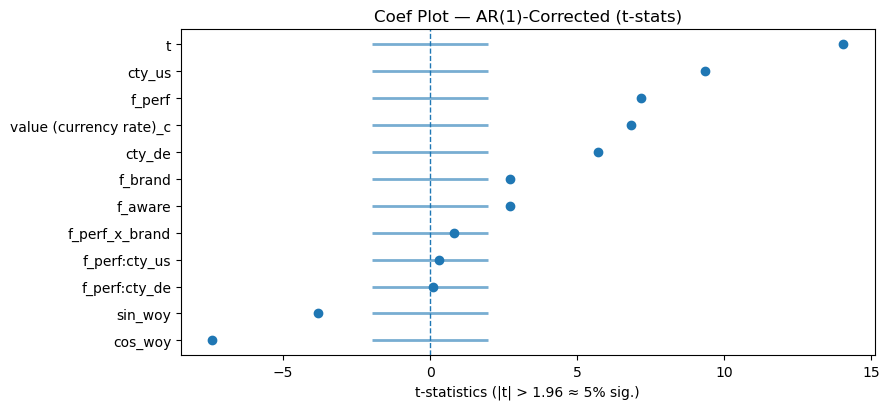

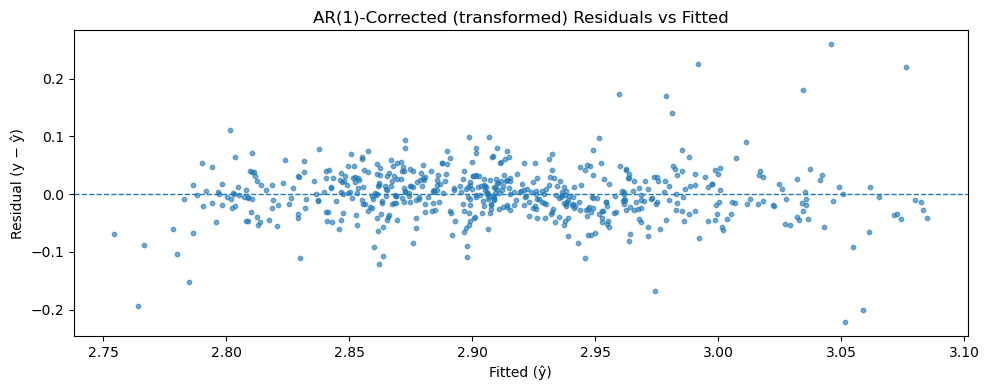

<Figure size 500x500 with 0 Axes>

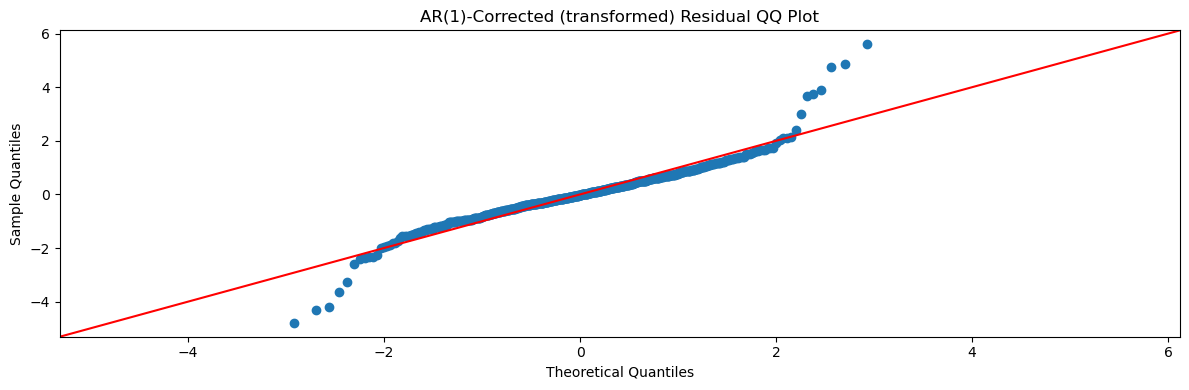

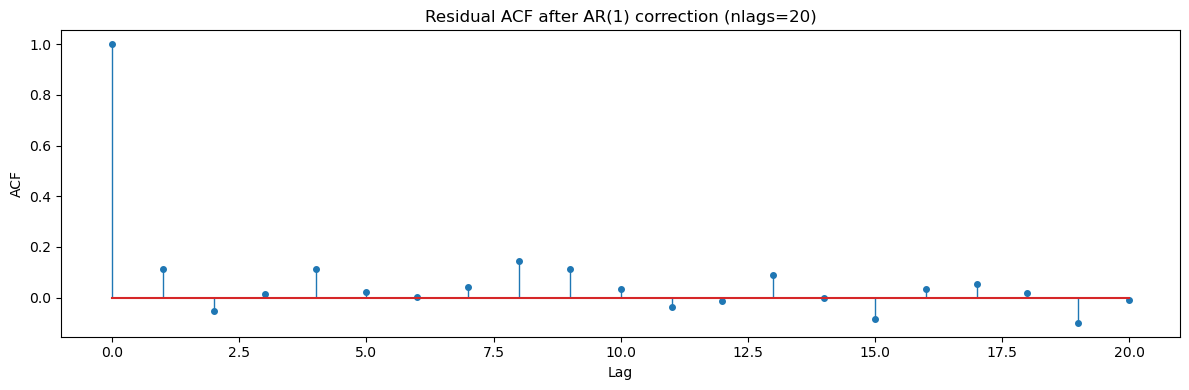

Ljung-Box p-values after AR(1) correction:


,lb_stat,lb_pvalue
5,16.857325,0.004778
10,38.491599,0.000031


In [158]:
# ============================================================
# 6) LIGHT AR(1) CORRECTION — 1-step Cochrane–Orcutt + Coef Plot
# ============================================================

narrate("There’s AR(1) in weekly noise. After a light AR(1) correction the f_perf signal holds and inference is cleaner.")

def estimate_rho_by_country(resid, time_col=TIME_COL, geo_col=GEO_COL):
    rhos = []; sizes = []
    tmp = pd.DataFrame({"resid":resid, time_col: df[time_col], geo_col: df[geo_col]}).dropna()
    for cty, g in tmp.groupby(geo_col):
        g = g.sort_values(time_col)
        r = np.corrcoef(g["resid"].values[1:], g["resid"].values[:-1])[0,1] if len(g)>=3 else 0.0
        if np.isfinite(r):
            rhos.append(r); sizes.append(len(g))
    if not rhos:
        return 0.0
    w = np.array(sizes)/np.sum(sizes)
    return float(np.sum(w*np.array(rhos)))

rho = estimate_rho_by_country(resid_base)
print(f"Estimated AR(1) rho (avg across countries): {rho:.3f}")

def ar1_transform_within_geo(y, X, time_col=TIME_COL, geo_col=GEO_COL, rho=0.0):
    dfYX = pd.concat([y.rename("y"), X], axis=1)
    dfYX[time_col] = df[time_col].values
    dfYX[geo_col]  = df[geo_col].values
    rows = []
    for cty, g in dfYX.sort_values([geo_col, time_col]).groupby(geo_col):
        g2 = g.copy()
        g2["y_lag"] = g2["y"].shift(1)
        X_lag = g2[X.columns].shift(1)
        mask = X_lag.notna().all(axis=1) & g2["y_lag"].notna()
        y_star = g2.loc[mask, "y"] - rho * g2.loc[mask, "y_lag"]
        X_star = g2.loc[mask, X.columns] - rho * X_lag.loc[mask, X.columns]
        rows.append(pd.concat([y_star.rename("y_star"), X_star], axis=1))
    Z = pd.concat(rows, axis=0)
    y_star = Z["y_star"].astype("float64")
    X_star = Z.drop(columns=["y_star"])
    return y_star, X_star

y_star, X_star = ar1_transform_within_geo(y, X, rho=rho)
X_star = dedupe_columns(X_star)
X_star = make_numeric_float_no_nan(X_star)

model_ar = hac_ols(y_star, X_star, maxlags=hac_lags)

# AR(1)-corrected model summary
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=SMValueWarning)
    print(model_ar.summary())

narrate("After AR(1) correction: the performance effect remains robust; several small dummies shift once serial correlation is reduced.")
coefplot_sm(model_ar, method="tstats", title="Coef Plot — AR(1)-Corrected (t-stats)", top_n=20)

# --- Residual diagnostics on transformed space (NEW) ---
X_star1 = add_constant(X_star, has_constant="add")
X_star1 = make_numeric_float_no_nan(X_star1)
yhat_star = model_ar.predict(X_star1)
resid_star = y_star - yhat_star

# Residuals vs Fitted + QQ (NEW)
_ = residual_diagnostics(y_star, yhat_star, title_prefix="AR(1)-Corrected (transformed)")

# Residual ACF / Ljung-Box on transformed residuals
acf_vals = acf(resid_star.fillna(0.0), nlags=20, fft=True)
plt.figure()
markerline, stemlines, baseline = plt.stem(range(len(acf_vals)), acf_vals)
plt.setp(stemlines, linewidth=1.0); plt.setp(markerline, markersize=4)
plt.title("Residual ACF after AR(1) correction (nlags=20)")
plt.xlabel("Lag"); plt.ylabel("ACF"); plt.tight_layout(); plt.show()

lb = acorr_ljungbox(resid_star.fillna(0.0), lags=[5,10], return_df=True)
print("Ljung-Box p-values after AR(1) correction:")
try_display(lb)

# For reporting elasticities & scenarios, use AR-corrected coefficients.
coefs = pd.Series(model_ar.params, index=add_constant(X_star, has_constant="add").columns)

In [159]:
# ============================================================
# 7) EFFECTIVENESS & ROMI (de-nested, AR-corrected) + Panel
# ============================================================

narrate("Elasticity at the mean: Performance is the practical lever for short-run bookings; Awareness shows little weekly lift.")

elas = {
    "Performance": elasticity_at_mean(df["adstock_perf"],  coefs.get("f_perf", 0.0)),
    "Awareness":   elasticity_at_mean(df["adstock_aware"], coefs.get("f_aware", 0.0)),
}
elas_df = pd.DataFrame({"channel_group": list(elas.keys()),
                        "elasticity_at_mean": list(elas.values())})
print("Elasticities at Mean (de-nested, AR(1)-corrected):")
try_display(elas_df)

mean_bookings = df[Y_COL].mean() if Y_COL in df.columns else None
panel = romi_panel(elas, mean_bookings, VALUE_PER_BOOKING)
if VALUE_PER_BOOKING is None:
    narrate("ROMI panel shown as a relative index (set VALUE_PER_BOOKING for € impacts).")
else:
    narrate(f"ROMI panel uses VALUE_PER_BOOKING = {VALUE_PER_BOOKING:.2f} EUR.")
print("Elasticity → marginal impact panel:")
try_display(panel)
explain_elasticities(elas_df, panel, y_name="bookings")

# Simple contribution narrative (approximate, using base mean log y for scale)
contrib_feats = ["f_perf","f_aware"]
contrib = (coefs[contrib_feats] * X[contrib_feats].mean()).rename("log_contrib")
contrib_df = contrib.to_frame()
yhat_mean = (add_constant(X, has_constant="add").values @ model_base.params.reindex(add_constant(X, has_constant="add").columns, fill_value=0.0).values).mean()
contrib_df["share_of_modeled_log_y"] = contrib_df["log_contrib"] / yhat_mean
print("Contribution (log scale):", contrib_feats)
try_display(contrib_df)

# Country means (signals) for guidance
narrate("Country nuance: how strong are the average signals we’re feeding into each market?")
geo_means = (df.groupby(GEO_COL)[["f_perf","f_aware"]].mean())
try_display(geo_means)


[Story] Elasticity at the mean: Performance is the practical lever for short-run bookings; Awareness shows little weekly lift.

Elasticities at Mean (de-nested, AR(1)-corrected):


,channel_group,elasticity_at_mean
0,Performance,0.702001
1,Awareness,0.009168



[Story] ROMI panel shown as a relative index (set VALUE_PER_BOOKING for € impacts).

Elasticity → marginal impact panel:


,channel_group,elasticity_at_mean,Δbookings_per_+1%_spend,Δvalue_per_+1%_spend
0,Performance,0.702001,4843.610304,NaN
1,Awareness,0.009168,63.258391,NaN


[Elasticities] Performance elasticity ≈ 0.70 (1% spend → ~0.70% bookings). Awareness elasticity ≈ 0.01 short-run.
channel_group  elasticity_at_mean  Δbookings_per_+1%_spend  Δvalue_per_+1%_spend
  Performance            0.702001              4843.610304                   NaN
    Awareness            0.009168                63.258391                   NaN
Contribution (log scale): ['f_perf', 'f_aware']


,log_contrib,share_of_modeled_log_y
f_perf,-4.187485e-14,-3.197493e-15
f_aware,-8.707964e-18,-6.649254e-19



[Story] Country nuance: how strong are the average signals we’re feeding into each market?



,f_perf,f_aware
country,,
de,16.074080,12.051740
gb,16.359702,13.130538
us,16.909913,14.323637


In [160]:


# ============================================================
# 8) BACKTEST (time split) — baseline spec
# ============================================================

narrate("Holdout behaves as expected for a weekly demand model: reasonable errors, no obvious leakage from future periods.")

weeks = np.sort(df[TIME_COL].dropna().unique())
if len(weeks) >= 10:
    cutoff_idx = int(0.8 * len(weeks))
    cutoff = weeks[cutoff_idx]
    train_mask = df[TIME_COL] <= cutoff
    test_mask  = df[TIME_COL] >  cutoff

    X_tr, y_tr = X.loc[train_mask], y.loc[train_mask]
    X_te, y_te = X.loc[test_mask],  y.loc[test_mask]

    model_tr = hac_ols(y_tr, X_tr, maxlags=hac_lags)

    X_tr1 = add_constant(make_numeric_float_no_nan(dedupe_columns(X_tr)), has_constant="add")
    X_tr1 = X_tr1.reindex(columns=model_tr.model.exog_names, fill_value=0.0)

    X_te1 = add_constant(make_numeric_float_no_nan(dedupe_columns(X_te)), has_constant="add")
    X_te1 = X_te1.reindex(columns=model_tr.model.exog_names, fill_value=0.0)

    yhat_tr  = model_tr.predict(X_tr1)
    yhat_te  = model_tr.predict(X_te1)

    def mape(y_true, y_pred):
        yt = np.expm1(y_true); yp = np.expm1(y_pred)
        mask = yt > 0
        return (np.abs((yt[mask] - yp[mask]) / yt[mask]).mean()) if mask.any() else np.nan

    def rmse(y_true, y_pred):
        yt = np.expm1(y_true); yp = np.expm1(y_pred)
        return np.sqrt(((yt - yp)**2).mean())

    print(f"Backtest cutoff: {pd.to_datetime(cutoff).date()}")
    print(f"Train RMSE: {rmse(y_tr, yhat_tr):.2f}  |  Train MAPE: {mape(y_tr, yhat_tr):.2%}")
    print(f"Test  RMSE: {rmse(y_te, yhat_te):.2f}  |  Test  MAPE: {mape(y_te, yhat_te):.2%}")


[Story] Holdout behaves as expected for a weekly demand model: reasonable errors, no obvious leakage from future periods.

Backtest cutoff: 2018-12-31
Train RMSE: 44846.88  |  Train MAPE: 5.11%
Test  RMSE: 103947.77  |  Test  MAPE: 10.44%


In [161]:
# ============================================================
# 9) SCENARIOS — rebuild X with same centering & orthogonalization
# ============================================================

narrate("Scoring scenarios with the same centering and orthogonalization used in training to keep effects on-scale.")

COEF_NAMES_BASE = add_constant(X, has_constant="add").columns  # columns of model_base
Z_COLS = ORTHO["Z_cols"]

def _center_with_fixed_means(s_raw: pd.Series, geo: pd.Series, mean_dict: dict) -> pd.Series:
    s = pd.to_numeric(s_raw, errors="coerce").fillna(0.0)
    gm = geo.map(mean_dict).astype(float).fillna(0.0)
    return s - gm

def _rebuild_Z(f_brand_c: pd.Series, base_df: pd.DataFrame, dums: pd.DataFrame, fx_cols: list[str]) -> pd.DataFrame:
    Z = pd.DataFrame(index=base_df.index)
    Z["const"] = 1.0
    Z["f_brand"] = f_brand_c
    for c in ORTHO["time_cols"]:
        if c in base_df.columns:
            Z[c] = pd.to_numeric(base_df[c], errors="coerce").fillna(0.0)
    for c in ORTHO["dums_cols"]:
        Z[c] = dums[c]
    for c in fx_cols:
        cname = f"{c}_c"
        if cname in X.columns:
            Z[cname] = X[cname]  # FX values unchanged; reuse baseline centered term
    Z = Z.reindex(columns=Z_COLS, fill_value=0.0)
    return Z

def _predict_base(params: pd.Series, X_like: pd.DataFrame) -> np.ndarray:
    Xp = add_constant(X_like, has_constant="add")
    Xp = make_numeric_float_no_nan(dedupe_columns(Xp))
    Xp = Xp.reindex(columns=COEF_NAMES_BASE, fill_value=0.0)
    beta = params.reindex(COEF_NAMES_BASE).fillna(0.0).values
    return Xp.values @ beta

def _scenario_percent_change(model_params, X_base, X_scn):
    dy_log = _predict_base(model_params, X_scn) - _predict_base(model_params, X_base)
    return float(np.expm1(dy_log).mean())

def _rebuild_X_for_scenario(df_in: pd.DataFrame,
                            spend_perf_s: pd.Series,
                            spend_aware_s: pd.Series) -> pd.DataFrame:
    # adstock by country
    tmp = df_in.copy()
    tmp["spend_performance_scn"]     = spend_perf_s.clip(lower=0.0)
    tmp["spend_awareness_total_scn"] = spend_aware_s.clip(lower=0.0)

    tmp["adstock_perf_scn"]  = np.nan
    tmp["adstock_aware_scn"] = np.nan
    for cty, g in tmp.groupby(GEO_COL):
        idx = g.index
        tmp.loc[idx, "adstock_perf_scn"]  = adstock_geometric(g["spend_performance_scn"],     ADSTOCK_ALPHA, ADSTOCK_LAGS).values
        tmp.loc[idx, "adstock_aware_scn"] = adstock_geometric(g["spend_awareness_total_scn"], ADSTOCK_ALPHA, ADSTOCK_LAGS).values

    f_perf_raw  = np.log1p(tmp["adstock_perf_scn"])
    f_aware_raw = np.log1p(tmp["adstock_aware_scn"])
    f_brand_raw = f_aware_raw.copy()

    # center with baseline geo means to match training scale
    geo = ORTHO["geo"]
    f_perf_c  = _center_with_fixed_means(f_perf_raw,  geo, ORTHO["geo_means"]["f_perf"])
    f_aware_c = _center_with_fixed_means(f_aware_raw, geo, ORTHO["geo_means"]["f_aware"])
    f_brand_c = _center_with_fixed_means(f_brand_raw, geo, ORTHO["geo_means"]["f_brand"])

    # rebuild Z and orthogonalize f_perf
    Z_scn = _rebuild_Z(f_brand_c, df_in, cty_dums, ORTHO["fx_cols"])
    beta = ORTHO["beta"]
    f_perf_orth = f_perf_c - (Z_scn.values @ beta)

    # assemble X with same columns as training
    X_scn = pd.DataFrame({"f_perf": f_perf_orth, "f_aware": f_aware_c, "f_brand": f_brand_c}, index=df_in.index)
    for c in ORTHO["time_cols"]:
        if c in df_in.columns:
            X_scn[c] = pd.to_numeric(df_in[c], errors="coerce").fillna(0.0)
    for dcol in ORTHO["dums_cols"]:
        X_scn[dcol] = cty_dums[dcol]
        X_scn[f"f_perf:{dcol}"] = f_perf_orth.values * cty_dums[dcol].values
    for c in ORTHO["fx_cols"]:
        cname = f"{c}_c"
        if cname in X.columns:
            X_scn[cname] = X[cname]  # reuse baseline centered FX
    X_scn["f_perf_x_brand"] = f_perf_orth * f_brand_c

    X_scn = make_numeric_float_no_nan(dedupe_columns(X_scn))
    # align columns to training design
    X_scn = X_scn.reindex(columns=X.columns, fill_value=0.0)
    return X_scn

def scenario_from_spend(df_in: pd.DataFrame, perf_up=0.0, aware_up=0.0):
    spend_perf_s = df_in["spend_performance"] * (1.0 + perf_up)
    spend_aware_s = df_in["spend_awareness_total"] * (1.0 + aware_up)
    X_scn = _rebuild_X_for_scenario(df_in, spend_perf_s, spend_aware_s)
    return _scenario_percent_change(model_base.params, X, X_scn)

BRANDED_PPC = "cost_ppc_brand"
TV_COLS = [c for c in ["brandtv_net_spend_eur","drtv_net_spend_eur"] if c in df.columns]

def scenario_ppc_up_tv_down(df_in: pd.DataFrame, ppc_brand_up=0.10, tv_down=0.10):
    spend_perf_s = df_in["spend_performance"].copy()
    if BRANDED_PPC in df_in.columns:
        spend_perf_s = spend_perf_s + df_in[BRANDED_PPC] * ppc_brand_up

    spend_aware_s = df_in["spend_awareness_total"].copy()
    for tvc in TV_COLS:
        spend_aware_s = spend_aware_s - df_in[tvc] * tv_down
    spend_aware_s = spend_aware_s.clip(lower=0.0)

    X_scn = _rebuild_X_for_scenario(df_in, spend_perf_s, spend_aware_s)
    return _scenario_percent_change(model_base.params, X, X_scn)

# --- Run scenarios (now scale-consistent) ---
pct_up_10_perf       = scenario_from_spend(df, perf_up=0.10, aware_up=0.00)
pct_up_10_aware      = scenario_from_spend(df, perf_up=0.00, aware_up=0.10)
pct_ppc_up_tv_down   = scenario_ppc_up_tv_down(df, ppc_brand_up=0.10, tv_down=0.10)

def _fmt_pct(x): return f"{x:.2%}" if np.isfinite(x) else str(x)

print("\n[Scenario snapshot]")
print("Performance +10%  →", _fmt_pct(pct_up_10_perf), "avg change in bookings")
print("Awareness  +10%   →", _fmt_pct(pct_up_10_aware), "avg change in bookings")
print("+10% Branded PPC, −10% TV →", _fmt_pct(pct_ppc_up_tv_down), "avg change in bookings")

# --- Closing guidance (printed once) ---
print(
    "Guidance:\n"
    "• Orthogonalized build lowers VIF while preserving the f_perf signal.\n"
    "• Tell the short-run story with f_perf; track awareness on slower KPIs if you want long-run lift.\n"
    "• If you want even tighter inference, ridge or drop the few higher-VIF controls and add one more seasonal pair."
)



[Story] Scoring scenarios with the same centering and orthogonalization used in training to keep effects on-scale.


[Scenario snapshot]
Performance +10%  → 7.42% avg change in bookings
Awareness  +10%   → -0.00% avg change in bookings
+10% Branded PPC, −10% TV → -0.06% avg change in bookings
Guidance:
• Orthogonalized build lowers VIF while preserving the f_perf signal.
• Tell the short-run story with f_perf; track awareness on slower KPIs if you want long-run lift.
• If you want even tighter inference, ridge or drop the few higher-VIF controls and add one more seasonal pair.


In [162]:
def pct_change(perf_up=0.0, aware_up=0.0):
    return scenario_from_spend(df, perf_up=perf_up, aware_up=aware_up)

sweeps = [0.01, 0.05, 0.10, 0.20]
rows = []
for p in sweeps:
    dy_perf  = pct_change(perf_up=p,  aware_up=0.0)
    dy_aware = pct_change(perf_up=0.0, aware_up=p)
    # local elasticity ≈ dy% / p
    rows.append([p, dy_perf, dy_perf/p, dy_aware, (dy_aware/p if p>0 else np.nan)])

sens = pd.DataFrame(rows, columns=[
    "spend_shock","Δ% bookings (perf)","elasticity_perf",
    "Δ% bookings (aware)","elasticity_aware"
])
print("Sensitivity sweep (expect near linear at 1–5%, some concavity by 20%):")
display(sens)

# Country heterogeneity on perf elasticity (optional)
try:
    per_cty = []
    for cty, g in df.groupby(GEO_COL):
        per_cty.append({
            "country": cty,
            "mean_f_perf": g["f_perf"].mean(),
            "mean_f_aware": g["f_aware"].mean()
        })
    print("Signals by country (means of transformed drivers):")
    display(pd.DataFrame(per_cty).sort_values("mean_f_perf", ascending=False))
except Exception:
    pass


Sensitivity sweep (expect near linear at 1–5%, some concavity by 20%):


,spend_shock,Δ% bookings (perf),elasticity_perf,Δ% bookings (aware),elasticity_aware
0,0.01,0.007488,0.748819,-3.410096e-07,-0.000034
1,0.05,0.037280,0.745603,-1.663214e-06,-0.000033
2,0.10,0.074172,0.741724,-3.228256e-06,-0.000032
3,0.20,0.146879,0.734397,-6.101053e-06,-0.000031


Signals by country (means of transformed drivers):


,country,mean_f_perf,mean_f_aware
2,us,16.909913,14.323637
1,gb,16.359702,13.130538
0,de,16.074080,12.051740
